# 04 — Consensus comparison and train/test/CV split

Part of a 5-notebook peptide-clustering + consensus-split exploration — see
`README_clustering.md` in this folder for the full picture and run order. This
notebook requires notebooks 01, 02, and 03 to have already been run (it reads all
four voter columns from `data/clustering/peptide_voters.parquet` and will raise a
clear error if any are missing).

**What this notebook does:**
1. Builds a pairwise co-association matrix from the four voter columns.
2. Runs **two independent consensus mechanisms** on it (hierarchical clustering on
   co-association distance, and Leiden community detection on a co-association-
   weighted graph) — both are functions of an explicit `voter_columns` list, so
   comparing e.g. all-four vs. without-QMAP is a one-line change, no upstream
   rerun needed.
3. Compares the two consensus partitions (adjusted Rand index + a table of peptides
   that land differently).
4. Builds a fresh train/test/CV split from whichever consensus partition you choose
   — by **whole cluster**, not individual peptide, so homologous/similar peptides
   never split across train and test the way a naive random split would risk.


In [1]:
import time
from pathlib import Path

import igraph as ig
import leidenalg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score


## Setup: load the shared voter table (all four methods must already be present)

In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root (no pyproject.toml found above cwd)")


REPO_ROOT = find_repo_root(Path.cwd())
DATA_DIR = REPO_ROOT / "data"
CLUSTERING_DIR = DATA_DIR / "clustering"
VOTERS_PATH = CLUSTERING_DIR / "peptide_voters.parquet"

if not VOTERS_PATH.exists():
    raise FileNotFoundError(
        f"{VOTERS_PATH} not found -- run notebooks 01, 02, and 03 first."
    )

peptide_voters = pd.read_parquet(VOTERS_PATH).reset_index(drop=True)
ALL_VOTER_COLUMNS = ["cluster_fingerprint", "cluster_descriptor", "cluster_peptideclm", "cluster_qmap"]
missing = [c for c in ALL_VOTER_COLUMNS if c not in peptide_voters.columns]
if missing:
    raise ValueError(
        f"Missing voter column(s) {missing} -- run the corresponding upstream notebook "
        "(01 for fingerprint/descriptor, 02 for peptideclm, 03 for qmap) first."
    )

print(peptide_voters.shape)
for col in ALL_VOTER_COLUMNS:
    print(f"  {col}: {peptide_voters[col].notna().sum()}/{len(peptide_voters)} scored, "
          f"{peptide_voters[col].nunique()} clusters")


(12371, 12)
  cluster_fingerprint: 12371/12371 scored, 611 clusters
  cluster_descriptor: 12371/12371 scored, 5 clusters
  cluster_peptideclm: 12371/12371 scored, 5 clusters
  cluster_qmap: 10888/12371 scored, 1504 clusters


## Co-association matrix

For every peptide pair, the fraction of methods (restricted to `voter_columns`) that
agree, **among only the methods that voted for both peptides in the pair** — a
method with a null vote for either peptide simply doesn't contribute to that pair's
numerator *or* denominator (handled explicitly below via a `valid` mask per method,
not by treating a null vote as its own cluster). Implemented as one-hot(labels) @
one-hot(labels).T per method (a null-voted peptide's one-hot row is all zeros, so it
contributes 0 to both the per-method agreement and, via a separately tracked
validity mask, is excluded from that method's contribution to the denominator too).

This is an O(n^2) computation (~12.4k^2 ≈ 153M pairs) but runs in a couple of
seconds thanks to it being one matrix multiply per method rather than a Python-level
double loop -- same "fast in wall-clock terms despite O(n^2)" tradeoff as notebook
01's Tanimoto distance matrix.


In [3]:
def compute_coassociation(df: pd.DataFrame, voter_columns: list[str]) -> np.ndarray:
    n = len(df)
    agree_sum = np.zeros((n, n), dtype=np.float32)
    valid_sum = np.zeros((n, n), dtype=np.float32)
    for col in voter_columns:
        codes, uniques = pd.factorize(df[col].values, use_na_sentinel=True)
        k = len(uniques)
        notna = codes >= 0
        onehot = np.zeros((n, k), dtype=np.float32)
        onehot[np.where(notna)[0], codes[notna]] = 1.0
        agree_sum += onehot @ onehot.T
        valid_sum += np.outer(notna, notna).astype(np.float32)

    coassoc = np.divide(agree_sum, valid_sum, out=np.zeros((n, n), dtype=np.float32), where=valid_sum > 0)
    np.fill_diagonal(coassoc, 1.0)
    n_zero_denom = int((valid_sum == 0).sum())
    if n_zero_denom:
        print(f"WARNING: {n_zero_denom} peptide pairs had no method voting for both -- "
              f"co-association set to 0 for these (max distance) rather than guessed.")
    return coassoc


_t0 = time.perf_counter()
coassociation = compute_coassociation(peptide_voters, ALL_VOTER_COLUMNS)
print(f"co-association matrix built in {time.perf_counter() - _t0:.1f}s, shape {coassociation.shape}")

distance_matrix = np.clip(1.0 - coassociation, 0.0, None)
np.fill_diagonal(distance_matrix, 0.0)


co-association matrix built in 2.0s, shape (12371, 12371)


## 4a. Co-association consensus: hierarchical clustering on (1 - co-association)

Agglomerative clustering with a precomputed distance matrix and average linkage --
a standard way to turn a co-association (consensus-clustering) matrix into a final
partition. `N_CONSENSUS_CLUSTERS` is the adjustable parameter requested in the task
(equivalently could expose a `distance_threshold` instead of a fixed cluster count --
left as `n_clusters` here since it makes the downstream test-fraction targeting in
step 6 more predictable). **Why 40, not something smaller like 10:** step 6 below
carves out a ~20% test set *and* splits the remainder into 4-5 folds, both by whole
cluster -- with only ~10 clusters total there often aren't enough "atoms" left after
the test carve-out to populate every fold (empirically, 3 of 5 folds came out empty
at `n_clusters=10` on this dataset). 40 was the smallest value that reliably
populates every fold here; rerun the cell below and check the fold-size output if
you change it.


In [4]:
N_CONSENSUS_CLUSTERS = 40  # adjustable -- see the "why 40" note above before lowering

_t0 = time.perf_counter()
consensus_coassoc_labels = AgglomerativeClustering(
    n_clusters=N_CONSENSUS_CLUSTERS, metric="precomputed", linkage="average",
).fit_predict(distance_matrix)
peptide_voters["consensus_coassoc"] = consensus_coassoc_labels
_sizes = peptide_voters["consensus_coassoc"].value_counts()
print(f"consensus_coassoc: {time.perf_counter() - _t0:.1f}s, {len(_sizes)} clusters, "
      f"sizes range {_sizes.min()}-{_sizes.max()} (median {_sizes.median():.0f})")
print("largest 5 clusters:", _sizes.head(5).to_dict())


consensus_coassoc: 1.8s, 40 clusters, sizes range 1-1784 (median 72)
largest 5 clusters: {13: 1784, 11: 1755, 8: 1692, 25: 1007, 1: 970}


## 4b. Vote-graph + Leiden: Leiden community detection directly on the co-association graph

Same underlying pairwise fractions as 4a, but consumed as edge weights of a graph
and partitioned with Leiden community detection instead of hierarchical clustering
-- the general-graph analogue of QMAP's own method (notebook 03), applied here to
the *vote* graph rather than a sequence-identity graph, using `leidenalg`/`igraph`
directly (both already dependencies of this project) rather than QMAP's
identity-graph-specific wrapper.

`MIN_EDGE_WEIGHT` sparsifies the graph -- without it, the graph would be
near-complete (any two peptides sharing even one voter's cluster get a nonzero edge)
and impractically dense to build. It also controls the resulting community count in
a distinctly non-linear way on this dataset -- 0.5 gives 10 large communities, 0.6
gives 16, but 0.7 jumps to 556 (mostly small) -- so 0.7 was chosen empirically here
to land in a comparable granularity range to `N_CONSENSUS_CLUSTERS=40` above (needed
for the same "enough atoms for 5 populated folds" reason). Adjustable; if you change
it, re-check the community count and (later) the fold-size output.


In [5]:
MIN_EDGE_WEIGHT = 0.7  # adjustable -- see the note above on why 0.7, not 0.5
LEIDEN_SEED = 42

_t0 = time.perf_counter()
n = len(peptide_voters)
iu = np.triu_indices(n, k=1)
pair_weights = coassociation[iu]
keep = pair_weights >= MIN_EDGE_WEIGHT
edges = np.column_stack([iu[0][keep], iu[1][keep]])
edge_weights = pair_weights[keep]
print(f"vote graph: {len(edges)} edges (of {len(pair_weights)} possible pairs, "
      f"{len(edges) / len(pair_weights):.1%}) after >= {MIN_EDGE_WEIGHT} thresholding")

vote_graph = ig.Graph(n=n, edges=edges.tolist(), directed=False)
vote_graph.es["weight"] = edge_weights.tolist()

partition = leidenalg.find_partition(
    vote_graph, leidenalg.ModularityVertexPartition, seed=LEIDEN_SEED,
    weights="weight", n_iterations=-1,
)
peptide_voters["consensus_votegraph"] = np.array(partition.membership)
_sizes = peptide_voters["consensus_votegraph"].value_counts()
print(f"consensus_votegraph: {time.perf_counter() - _t0:.1f}s total, {len(_sizes)} clusters, "
      f"sizes range {_sizes.min()}-{_sizes.max()} (median {_sizes.median():.0f})")
print("largest 5 clusters:", _sizes.head(5).to_dict())


vote graph: 1102224 edges (of 76514635 possible pairs, 1.4%) after >= 0.7 thresholding


consensus_votegraph: 7.4s total, 556 clusters, sizes range 1-1530 (median 1)
largest 5 clusters: {0: 1530, 1: 1163, 2: 1131, 3: 1103, 4: 910}


## Step 5: compare the two consensus partitions

Adjusted Rand index (chance-corrected agreement between two partitions, 1.0 =
identical, ~0.0 = no better than random) plus a look at which peptides actually land
in different consensus groups depending on method, so you can judge whether the two
mechanisms roughly agree or meaningfully diverge before picking one.


Adjusted Rand Index (consensus_coassoc vs. consensus_votegraph): 0.462


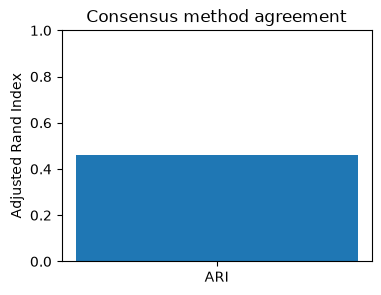

In [6]:
ari_consensus_vs_consensus = adjusted_rand_score(
    peptide_voters["consensus_coassoc"], peptide_voters["consensus_votegraph"],
)
print(f"Adjusted Rand Index (consensus_coassoc vs. consensus_votegraph): {ari_consensus_vs_consensus:.3f}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["ARI"], [ari_consensus_vs_consensus])
ax.set_ylim(0, 1)
ax.set_ylabel("Adjusted Rand Index")
ax.set_title("Consensus method agreement")
plt.show()


In [7]:
# A peptide "lands differently" if the two partitions disagree about which OTHER
# peptides it's grouped with -- co-cluster-membership disagreement, not raw label
# equality (cluster label numbers between the two methods aren't aligned to begin
# with). Approximate this via: for each peptide, does its most common co-clustered
# neighbor set differ between the two partitions? A simpler, exact proxy used here:
# cross-tabulate the two partitions and flag peptides whose (coassoc_cluster,
# votegraph_cluster) pair is a minority combination within their coassoc_cluster.
crosstab = pd.crosstab(peptide_voters["consensus_coassoc"], peptide_voters["consensus_votegraph"])
majority_votegraph_per_coassoc = crosstab.idxmax(axis=1)
peptide_voters["_majority_votegraph_for_its_coassoc_cluster"] = (
    peptide_voters["consensus_coassoc"].map(majority_votegraph_per_coassoc)
)
disagreement_mask = (
    peptide_voters["consensus_votegraph"] != peptide_voters["_majority_votegraph_for_its_coassoc_cluster"]
)
print(f"{disagreement_mask.sum()}/{len(peptide_voters)} peptides ({disagreement_mask.mean():.1%}) are NOT in "
      f"the votegraph cluster that's the majority choice for their co-association cluster")
peptide_voters.drop(columns=["_majority_votegraph_for_its_coassoc_cluster"], inplace=True)

display_cols = ["peptide_id", "sequence", "consensus_coassoc", "consensus_votegraph"]
peptide_voters.loc[disagreement_mask, display_cols].head(10)


4610/12371 peptides (37.3%) are NOT in the votegraph cluster that's the majority choice for their co-association cluster


,peptide_id,sequence,consensus_coassoc,consensus_votegraph
3,13,RRXXRF,13,207
5,15,DSHAKRHHGYKRKFHEKHHSHRGY,10,208
10,51,KLlK,8,9
11,52,KWLNALLHHGLNCAKGVLA,11,2
12,55,WLNALLHHGLNCAKGVLA,15,209
32,104,GLRKRLRKFRNKIKEKLKKI,11,7
33,105,SwFkTkSk,3,63
34,106,sWfKtKsK,3,63
45,123,GIGKFIHSVKKWGKTFIGEIMNS,11,12
49,130,GLRKRLRKARNKIKEKLKKI,11,7


## Step 6: build the train/test/CV split from the chosen consensus partition

**The single switch governing everything below** -- change this to
`"consensus_votegraph"` to use that partition instead, no other cell needs editing.


In [8]:
CHOSEN_CONSENSUS = "consensus_coassoc"  # or "consensus_votegraph"

chosen_labels = peptide_voters[CHOSEN_CONSENSUS]
print(f"using {CHOSEN_CONSENSUS}: {chosen_labels.nunique()} clusters over {len(peptide_voters)} peptides")


using consensus_coassoc: 40 clusters over 12371 peptides


### 6a. Test carve-out (~20%, whole clusters only)

Shuffle clusters, then greedily add whole clusters to the test set until the target
fraction of *peptides* (not clusters) is reached -- the same greedy whole-cluster
strategy QMAP's own `train_test_split` uses internally (`qmap.toolkit.split.
train_test_split.random_cluster_split`), applied here to consensus clusters instead
of QMAP's native sequence-identity-only clusters.


In [9]:
TARGET_TEST_FRACTION = 0.20  # adjustable
TEST_SPLIT_SEED = 42

cluster_sizes = chosen_labels.value_counts()


def greedy_whole_cluster_test_split(sizes: pd.Series, target_fraction: float, seed: int):
    shuffled = sizes.sample(frac=1, random_state=seed)
    total = int(shuffled.sum())
    cumulative = 0
    chosen = []
    for cluster_id, size in shuffled.items():
        chosen.append(cluster_id)
        cumulative += int(size)
        if cumulative / total >= target_fraction:
            break
    return chosen, cumulative / total


test_clusters, resulting_test_fraction = greedy_whole_cluster_test_split(
    cluster_sizes, TARGET_TEST_FRACTION, TEST_SPLIT_SEED,
)
print(f"greedy selection: {len(test_clusters)} clusters -> {resulting_test_fraction:.1%} of peptides in test "
      f"(target was {TARGET_TEST_FRACTION:.0%})")
print(f"test cluster ids: {test_clusters}")


greedy selection: 12 clusters -> 21.8% of peptides in test (target was 20%)
test cluster ids: [22, 28, 3, 34, 1, 17, 38, 21, 33, 9, 20, 15]


**Manually adjust here if the fraction above is off-target** -- add or remove
cluster ids (from the full list printed by `cluster_sizes` above) and rerun this
cell and the ones below it.


In [10]:
MANUAL_TEST_CLUSTER_ADDITIONS = []   # e.g. [3, 7]
MANUAL_TEST_CLUSTER_REMOVALS = []    # e.g. [1]

final_test_clusters = (set(test_clusters) | set(MANUAL_TEST_CLUSTER_ADDITIONS)) - set(MANUAL_TEST_CLUSTER_REMOVALS)
final_test_fraction = cluster_sizes.loc[list(final_test_clusters)].sum() / cluster_sizes.sum()
print(f"final: {len(final_test_clusters)} test clusters, {final_test_fraction:.1%} of peptides")


final: 12 test clusters, 21.8% of peptides


### 6b. CV folds from the remaining ~80%

Same cumulative-sum-binning approach already proven in
`scripts/EDA/generate_leiden_train_folds.ipynb` (shuffle clusters, cumulative size,
`pd.cut` into N roughly-equal-mass bins) -- guarantees no cluster (and therefore no
group of peptides the consensus judged similar) is ever split across folds.


fold sizes (peptides):
count
0     498
1    2109
2    3218
3    1712
4    2134
Name: count, dtype: int64


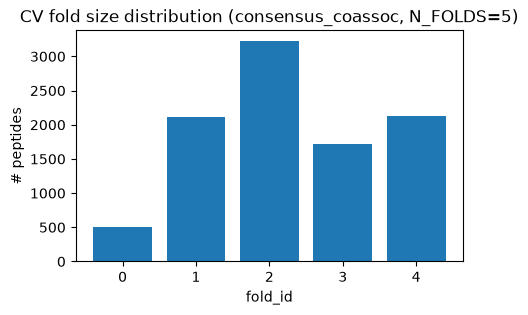

In [11]:
N_FOLDS = 5  # adjustable (4-5 requested)
FOLD_SPLIT_SEED = 42

train_pool_sizes = cluster_sizes.drop(index=list(final_test_clusters))
shuffled_train_clusters = train_pool_sizes.sample(frac=1, random_state=FOLD_SPLIT_SEED)
cumulative_sizes = shuffled_train_clusters.cumsum()
fold_bins = pd.cut(cumulative_sizes, bins=N_FOLDS, labels=False)
cluster_to_fold = dict(zip(shuffled_train_clusters.index, fold_bins))

fold_sizes = shuffled_train_clusters.groupby(fold_bins).sum()
print("fold sizes (peptides):")
print(fold_sizes)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(fold_sizes.index.astype(str), fold_sizes.values)
ax.set_xlabel("fold_id")
ax.set_ylabel("# peptides")
ax.set_title(f"CV fold size distribution ({CHOSEN_CONSENSUS}, N_FOLDS={N_FOLDS})")
plt.show()


### Assemble the final peptide-level split and propagate to every organism-row

Writes `data/clustering/consensus_split.csv`, one row per unique `peptide_id`
(`node_id`/`community`/`fold_id`-shaped, like `data/train_folds_leiden.csv`, so it's
a drop-in alternative input to the same `build_dataset(row_groups=...)` pattern
`scripts/EDA/build_dataset_build_model_kfold_demo.ipynb` already demonstrates), plus
an organism-row-level copy merged back onto the full classification dataset.


In [12]:
def assign_split(cluster_id):
    if cluster_id in final_test_clusters:
        return "test", np.nan
    return "train", cluster_to_fold[cluster_id]


split_assignments = chosen_labels.map(assign_split)
peptide_voters["split"] = [s for s, _ in split_assignments]
peptide_voters["fold_id"] = [f for _, f in split_assignments]

consensus_split = peptide_voters[[
    "peptide_id", "cluster_fingerprint", "cluster_descriptor", "cluster_peptideclm", "cluster_qmap",
    "consensus_coassoc", "consensus_votegraph", "split", "fold_id", "is_linear",
]].copy()
# "community" mirrors the CHOSEN_CONSENSUS column under the same generic name
# data/train_folds_leiden.csv uses, so this file is a drop-in alternative there --
# consensus_coassoc/consensus_votegraph above are kept too so BOTH are still visible.
consensus_split["community"] = peptide_voters[CHOSEN_CONSENSUS]

CLUSTERING_DIR.mkdir(exist_ok=True)
consensus_split.to_csv(CLUSTERING_DIR / "consensus_split.csv", index=False)
print(f"saved {CLUSTERING_DIR / 'consensus_split.csv'} ({len(consensus_split)} rows)")

print(consensus_split["split"].value_counts())
print(consensus_split.groupby("split", dropna=False)["fold_id"].value_counts(dropna=False))


saved /Users/lukajin/PycharmProjects/soamp/data/clustering/consensus_split.csv (12371 rows)
split
train    9671
test     2700
Name: count, dtype: int64
split  fold_id
test   NaN        2700
train  2.0        3218
       4.0        2134
       1.0        2109
       3.0        1712
       0.0         498
Name: count, dtype: int64
